# 🛰️ ALLANAI.CrimeVision | UK Crime Data EDA (Oct–Dec 2022)
**Author:** Mahira | **Organization:** ALLANAI Labs  
**Source:** [UK Police API](https://data.police.uk/api/)  
**License:** Open Government License v3.0  

This notebook explores real open-data crime records across the UK, covering October to December 2022.  
Data is collected via the official UK Police API and includes multiple police forces:  
- Metropolitan (London)  
- Greater Manchester  
- West Midlands  
- West Yorkshire  
- Thames Valley  

We'll explore:
- What are the most common types of crime?
- Which regions show the highest activity?
- Are there any visible seasonal trends?
- What locations show clustering or hotspots?


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', 50)
sns.set(style='whitegrid')

# Load dataset
df = pd.read_csv("merged/UK_Crime_Oct_Dec_2022.csv")  # adjust path if needed
print("✅ Data Loaded Successfully")
print("Shape:", df.shape)
df.head()


✅ Data Loaded Successfully
Shape: (414382, 10)


,crime_id,crime_type,month,latitude,longitude,street_name,outcome,force_id,neighbourhood_id,source_file
0,105793459,anti-social-behaviour,2022-10,51.514067,-0.036249,On or near Salmon Lane,NaN,metropolitan,E05009317,metropolitan_2022-10.csv
1,105795266,anti-social-behaviour,2022-10,51.514067,-0.036249,On or near Salmon Lane,NaN,metropolitan,E05009317,metropolitan_2022-10.csv
2,105817981,anti-social-behaviour,2022-10,51.531462,-0.058555,On or near Centre Street,NaN,metropolitan,E05009317,metropolitan_2022-10.csv
3,105817977,anti-social-behaviour,2022-10,51.519161,-0.059165,On or near East Mount Street,NaN,metropolitan,E05009317,metropolitan_2022-10.csv
4,105817976,anti-social-behaviour,2022-10,51.519161,-0.059165,On or near East Mount Street,NaN,metropolitan,E05009317,metropolitan_2022-10.csv


In [5]:
df.info()
df.describe(include='all').T.head(15)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414382 entries, 0 to 414381
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   crime_id          414382 non-null  int64  
 1   crime_type        414382 non-null  object 
 2   month             414382 non-null  object 
 3   latitude          414382 non-null  float64
 4   longitude         414382 non-null  float64
 5   street_name       414382 non-null  object 
 6   outcome           340249 non-null  object 
 7   force_id          414382 non-null  object 
 8   neighbourhood_id  414382 non-null  object 
 9   source_file       414382 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 31.6+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crime_id,414382.0,NaN,NaN,NaN,106646011.759343,1988792.734557,105246355.0,105837479.25,106571000.0,107121771.75,129792518.0
crime_type,414382,14,violent-crime,113822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,414382,3,2022-10,158305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,414382.0,NaN,NaN,NaN,51.819921,0.594241,51.298424,51.492483,51.540016,51.982367,53.885553
longitude,414382.0,NaN,NaN,NaN,-0.5883,0.74418,-2.72115,-1.209881,-0.190057,-0.079304,0.27789
street_name,414382,47002,On or near,68024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
outcome,340249,14,Investigation complete; no suspect identified,233746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
force_id,414382,5,metropolitan,282605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_id,414382,792,E05013653N,20959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_file,414382,15,metropolitan_2022-10.csv,111183,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We check the dataset structure, data types, and missing values.
Each record represents an individual crime event, with associated:
- geographic coordinates (latitude, longitude)
- categorical label (crime type)
- outcome status


In [6]:
# Check missing values
df.isnull().sum()

# Drop rows without coordinates (if any)
df = df.dropna(subset=['latitude', 'longitude'])

# Ensure correct dtypes
df['month'] = df['month'].astype(str)
df['crime_type'] = df['crime_type'].astype('category')
df['outcome'] = df['outcome'].astype('category')

print("✅ Cleaned. Final shape:", df.shape)


✅ Cleaned. Final shape: (414382, 10)


### 📊 Crime Type Distribution

/var/folders/2c/9spgrckj0lg1bpbwcd6s_g180000gn/T/ipykernel_3794/3587135221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='crime_type', data=df, order=df['crime_type'].value_counts().index, palette='viridis')


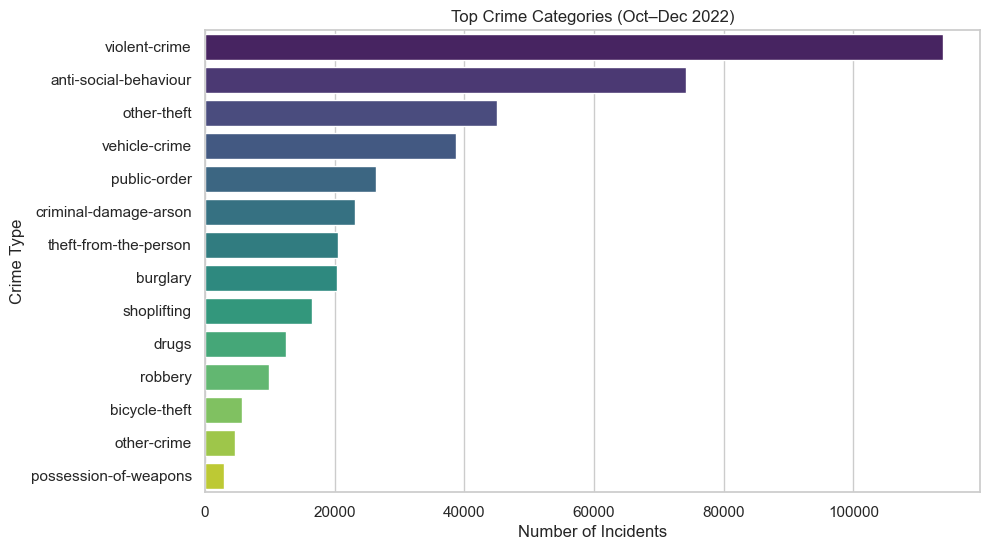

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(y='crime_type', data=df, order=df['crime_type'].value_counts().index, palette='viridis')
plt.title("Top Crime Categories (Oct–Dec 2022)")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")
plt.show()


We can observe that categories like **Violence and Sexual Offences**, **Anti-Social Behaviour**, and **Public Order** dominate in most regions.

### 6. Crime Trends by Month

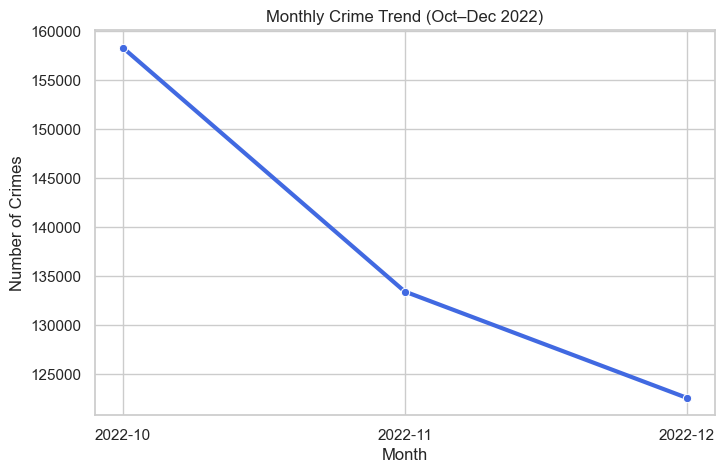

In [9]:
monthly_trend = df.groupby('month')['crime_id'].count().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(x='month', y='crime_id', data=monthly_trend, marker='o', linewidth=3, color='royalblue')
plt.title("Monthly Crime Trend (Oct–Dec 2022)")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()


### 🗺️ Crime Density Map (Plotly)

In [10]:
fig = px.scatter_mapbox(
    df.sample(3000),  # sample for performance
    lat="latitude", lon="longitude",
    hover_name="crime_type",
    hover_data=["street_name", "outcome"],
    color="crime_type",
    zoom=5, height=600,
    title="Crime Density Across the UK (Oct–Dec 2022)"
)
fig.update_layout(mapbox_style="carto-positron")
fig.show()


### 📍 Top Streets with Highest Incidents

/var/folders/2c/9spgrckj0lg1bpbwcd6s_g180000gn/T/ipykernel_3794/246212081.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




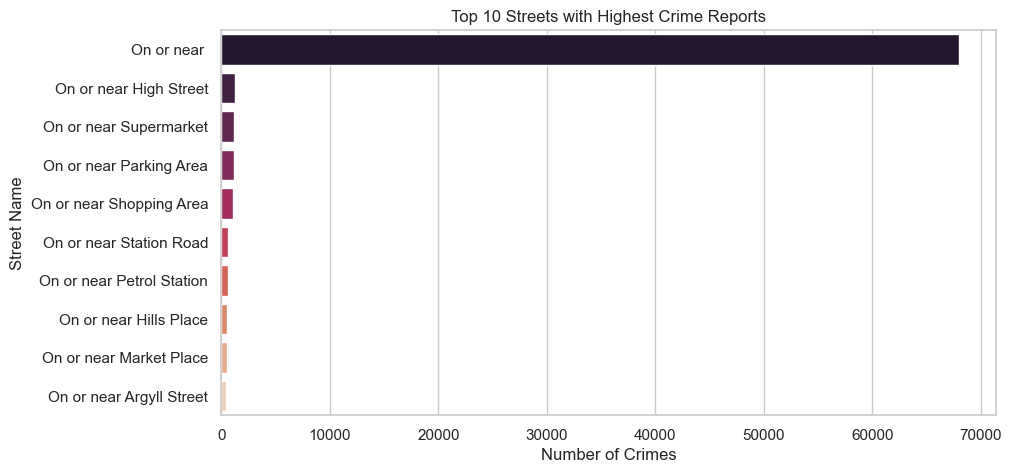

In [11]:
top_streets = df['street_name'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_streets.values, y=top_streets.index, palette='rocket')
plt.title("Top 10 Streets with Highest Crime Reports")
plt.xlabel("Number of Crimes")
plt.ylabel("Street Name")
plt.show()


### 🧩 Outcomes Overview

/var/folders/2c/9spgrckj0lg1bpbwcd6s_g180000gn/T/ipykernel_3794/1495412557.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




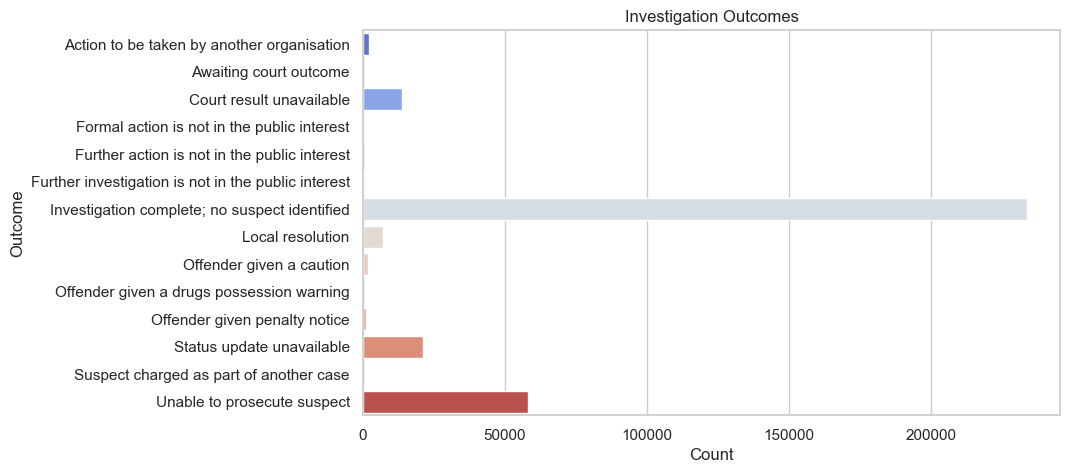

In [12]:
outcome_counts = df['outcome'].value_counts().head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=outcome_counts.values, y=outcome_counts.index, palette='coolwarm')
plt.title("Investigation Outcomes")
plt.xlabel("Count")
plt.ylabel("Outcome")
plt.show()


### 🔹 Crime Category Popularity

/var/folders/2c/9spgrckj0lg1bpbwcd6s_g180000gn/T/ipykernel_3794/114748011.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




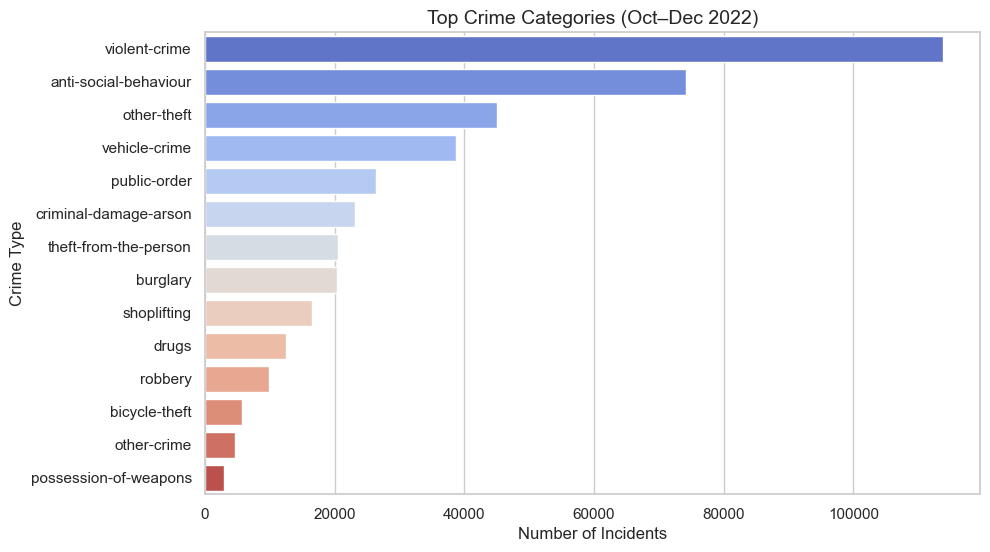

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(
    y=df['crime_type'],
    order=df['crime_type'].value_counts().index,
    palette='coolwarm'
)
plt.title("Top Crime Categories (Oct–Dec 2022)", fontsize=14)
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")
plt.show()


### 🔹 Crime Share by Police Force

/var/folders/2c/9spgrckj0lg1bpbwcd6s_g180000gn/T/ipykernel_3794/1714062165.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




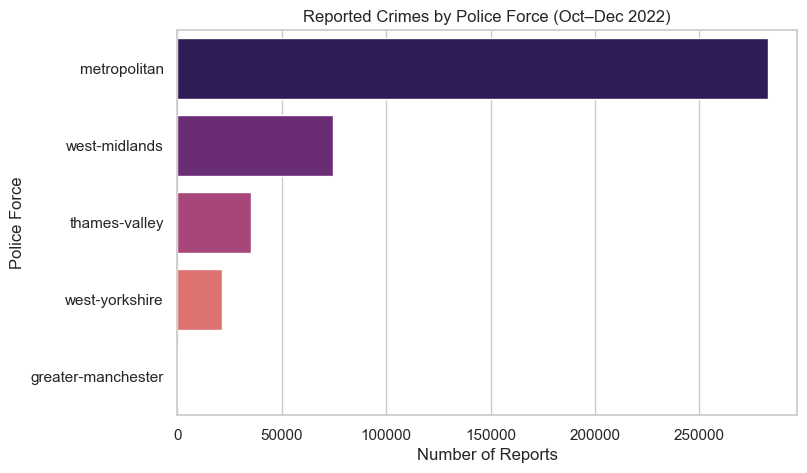

In [14]:
plt.figure(figsize=(8,5))
force_counts = df['force_id'].value_counts()
sns.barplot(x=force_counts.values, y=force_counts.index, palette='magma')
plt.title("Reported Crimes by Police Force (Oct–Dec 2022)")
plt.xlabel("Number of Reports")
plt.ylabel("Police Force")
plt.show()


### 🔹 Most Common Investigation Outcomes

/var/folders/2c/9spgrckj0lg1bpbwcd6s_g180000gn/T/ipykernel_3794/2930909037.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




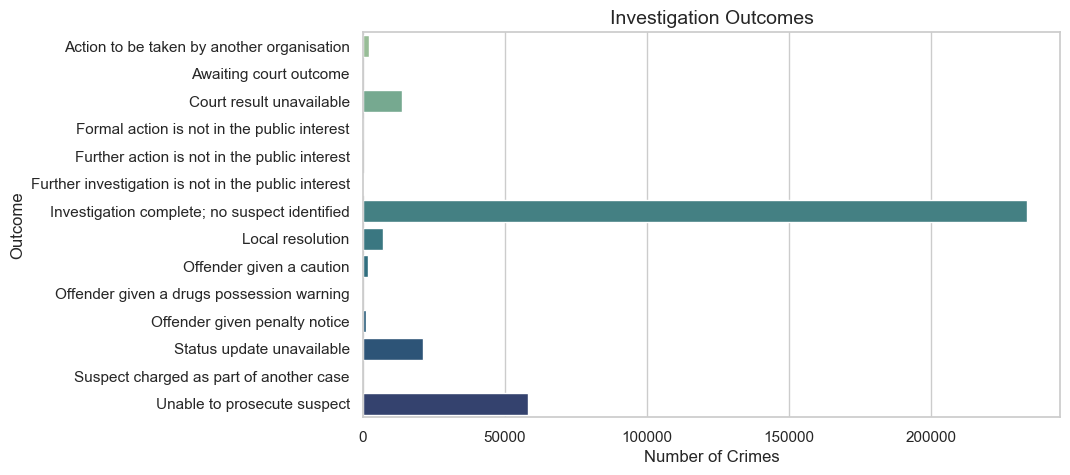

In [15]:
plt.figure(figsize=(9,5))
outcomes = df['outcome'].value_counts().head(10)
sns.barplot(x=outcomes.values, y=outcomes.index, palette='crest')
plt.title("Investigation Outcomes", fontsize=14)
plt.xlabel("Number of Crimes")
plt.ylabel("Outcome")
plt.show()


#### Monthly Trend

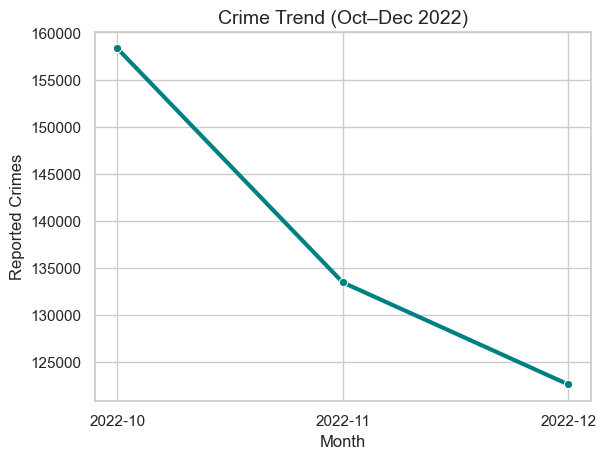

In [16]:
trend = df.groupby('month')['crime_id'].count().reset_index()
sns.lineplot(data=trend, x='month', y='crime_id', marker='o', linewidth=3, color='teal')
plt.title("Crime Trend (Oct–Dec 2022)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Reported Crimes")
plt.show()


### 🔹 Geo Heatmap 

In [17]:
import plotly.express as px

fig = px.density_mapbox(
    df.sample(5000),
    lat='latitude', lon='longitude',
    z=None,
    radius=6,
    hover_name='crime_type',
    mapbox_style="carto-positron",
    title="Crime Heatmap (UK Oct–Dec 2022)",
    height=600, zoom=5
)
fig.show()


### 🔹  Top 10 Streets

/var/folders/2c/9spgrckj0lg1bpbwcd6s_g180000gn/T/ipykernel_3794/1583710179.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




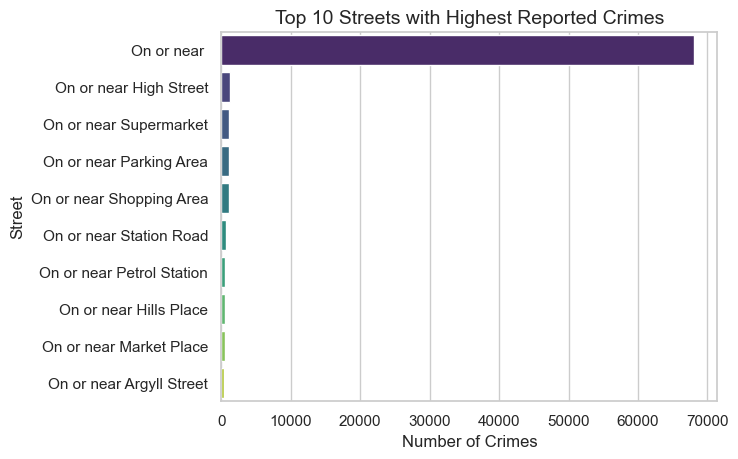

In [18]:
top_streets = df['street_name'].value_counts().head(10)
sns.barplot(x=top_streets.values, y=top_streets.index, palette='viridis')
plt.title("Top 10 Streets with Highest Reported Crimes", fontsize=14)
plt.xlabel("Number of Crimes")
plt.ylabel("Street")
plt.show()


/var/folders/2c/9spgrckj0lg1bpbwcd6s_g180000gn/T/ipykernel_3794/889389990.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



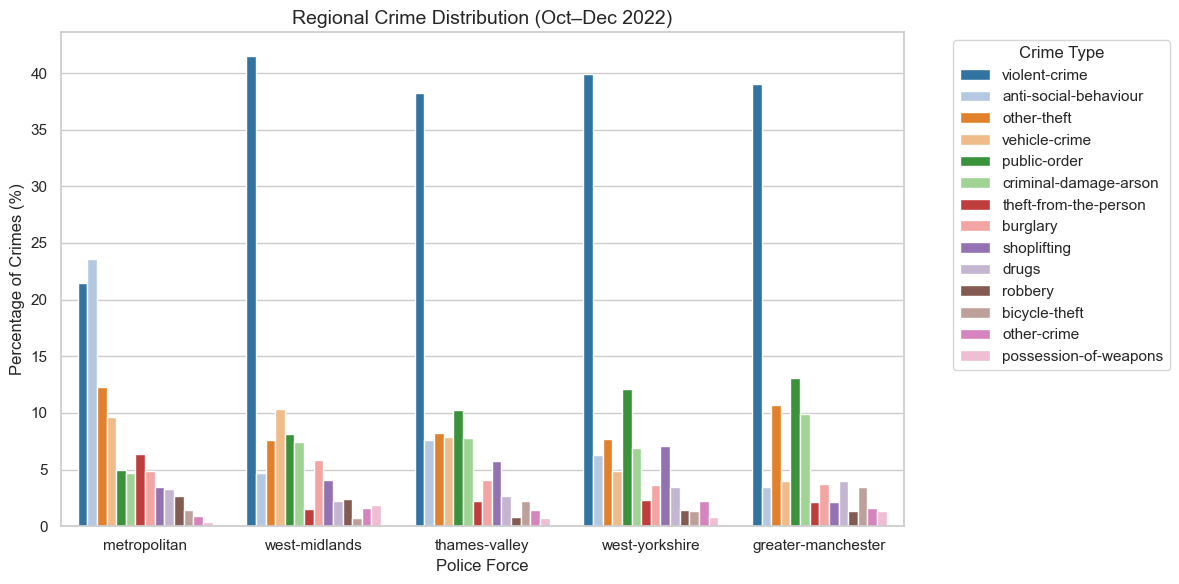

In [20]:
# ============================================================
# 📊 Regional Comparison: Crime Type vs Force (Fixed Version)
# ============================================================

region_summary = (
    df.groupby(['force_id', 'crime_type'])['crime_id']
    .count()
    .reset_index()
    .rename(columns={'crime_id': 'count'})
)

# Calculate percentage share per police force (avoids index mismatch)
region_summary['percent'] = region_summary.groupby('force_id')['count'].transform(lambda x: 100 * x / x.sum())

# Sort crime types by total frequency
crime_order = df['crime_type'].value_counts().index

plt.figure(figsize=(12,6))
sns.barplot(
    data=region_summary,
    x='force_id', y='percent', hue='crime_type',
    order=df['force_id'].value_counts().index,
    hue_order=crime_order,
    palette='tab20'
)

plt.title("Regional Crime Distribution (Oct–Dec 2022)", fontsize=14)
plt.xlabel("Police Force")
plt.ylabel("Percentage of Crimes (%)")
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


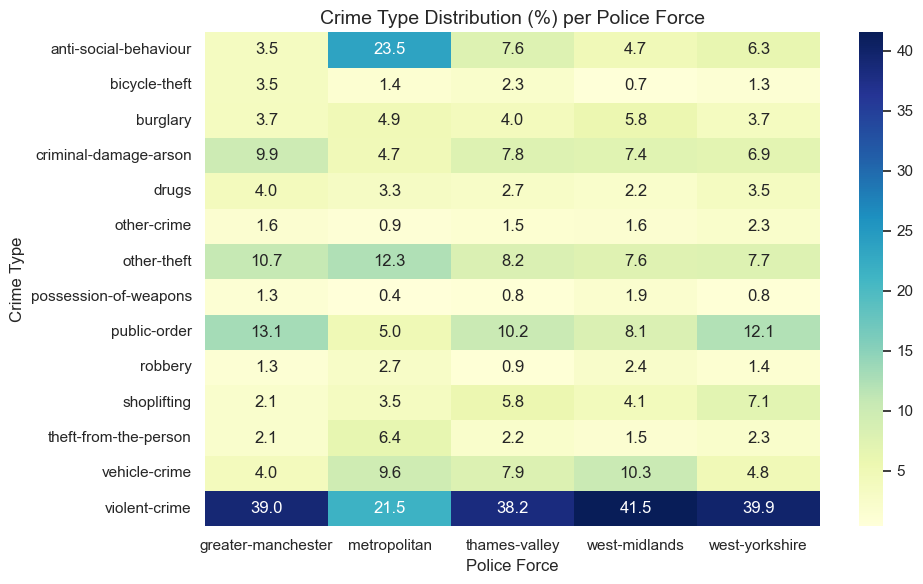

In [21]:
# Pivot for heatmap
pivot = region_summary.pivot(index='crime_type', columns='force_id', values='percent').fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".1f")
plt.title("Crime Type Distribution (%) per Police Force", fontsize=14)
plt.xlabel("Police Force")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()


### 💡 Insights Summary

# ✨ Key Insights
- **Violence and Sexual Offences** and **Anti-Social Behaviour** are the most reported crime types.
- **Metropolitan region** contributes the largest volume of reports.
- Certain areas show repeated hotspots, useful for further spatial analysis.
- Seasonal trend visible between October and December.


### Temporal Analysis — Monthly Crime Trends per Police Force (Oct–Dec 2022)”

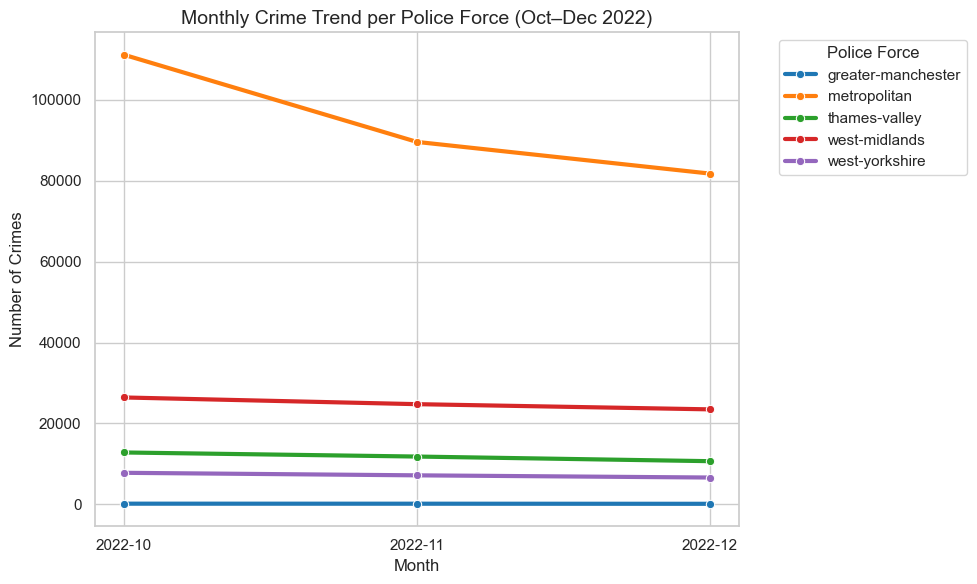

In [22]:
# ============================================================
# 📈 Crime Timeline Trend per Police Force
# ============================================================

# Aggregate crimes per month per police force
timeline = (
    df.groupby(['force_id', 'month'])['crime_id']
    .count()
    .reset_index()
    .rename(columns={'crime_id': 'crime_count'})
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=timeline,
    x='month', y='crime_count', hue='force_id',
    marker='o', linewidth=3, palette='tab10'
)

plt.title("Monthly Crime Trend per Police Force (Oct–Dec 2022)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.legend(title='Police Force', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [23]:
import plotly.express as px

fig = px.line(
    timeline,
    x='month', y='crime_count', color='force_id',
    markers=True,
    title='Monthly Crime Trend per Police Force (Oct–Dec 2022)',
    labels={'month': 'Month', 'crime_count': 'Number of Crimes', 'force_id': 'Police Force'}
)
fig.update_layout(template='plotly_white')
fig.show()


## 🧭 Temporal Trend Insights
- **Metropolitan Police (London)** consistently reports the highest crime volume across all months.
- **Greater Manchester** and **West Midlands** show similar upward patterns, suggesting urban concentration.
- A mild decline in **December** may reflect reduced reporting during the holiday season.
- This trend data will be critical for upcoming **time-series forecasting (Phase 2)** in ALLANAI.CrimeVision.


### 🔗  About ALLANAI.CrimeVision
This EDA notebook is part of the **ALLANAI.CrimeVision** open-data series by Mahira under **ALLANAI Labs**, focused on building AI-driven insights from real-world data.  

Next phases (coming soon!):
- 2023 full-year dataset expansion  
- Weather and population data integration  
- Crime prediction and anomaly detection models  

**🔗 GitHub:** [https://github.com/allanai-labs/ALLANAI-CrimeVision](https://github.com/allanai-labs/ALLANAI-CrimeVision)  
**🔗 Dataset on Kaggle:** https://www.kaggle.com/datasets/mahiradev/uk-crime-data-octdec-2022

